In [1]:
import pandas as pd
import os
name = '睡袋&睡袋.xlsx'
data_dir = 'C:/Develop/深圳42/data/report/'
df = pd.read_excel(data_dir+name,parse_dates=[0])

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   日期      480 non-null    datetime64[ns]
 1   品牌      480 non-null    object        
 2   访客数     480 non-null    int64         
 3   转化率     480 non-null    float64       
 4   客单价     480 non-null    int64         
 5   三级类目    480 non-null    object        
 6   详细类目    480 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 26.4+ KB


In [3]:
df.describe()

,访客数,转化率,客单价
count,4.800000e+02,480.000000,480.000000
mean,3.004245e+05,0.046030,184.275000
std,6.994473e+05,0.017975,207.782143
min,2.034900e+04,0.006851,47.000000
25%,1.070215e+05,0.034234,96.750000
50%,1.783300e+05,0.043899,130.000000
75%,2.995410e+05,0.055205,166.250000
max,1.076508e+07,0.197836,1222.000000


In [4]:
# 新建一列, 销售额
df['销售额'] = df['访客数']*df['转化率']*df['客单价']

In [5]:
# 筛选2023年的数据
df['年份'] = df['日期'].dt.year
df_2023 = df[df['年份']==2023]

In [6]:
# 统计每个品牌的23年的总销售额
result_df = df_2023.groupby(['品牌'],as_index=False)['销售额'].sum()
result_df['类目'] = name.replace('.xlsx','')

In [7]:
result_df

,品牌,销售额,类目
0,品牌-1,3.074469e+07,睡袋&睡袋
1,品牌-10,2.324706e+07,睡袋&睡袋
2,品牌-11,2.587722e+07,睡袋&睡袋
3,品牌-12,2.697452e+07,睡袋&睡袋
4,品牌-13,2.909656e+07,睡袋&睡袋
5,品牌-14,3.540371e+07,睡袋&睡袋
6,品牌-15,3.704306e+07,睡袋&睡袋
7,品牌-16,3.045923e+07,睡袋&睡袋
8,品牌-17,2.819333e+07,睡袋&睡袋
9,品牌-18,3.430548e+07,睡袋&睡袋


In [8]:
df = pd.read_excel(data_dir+name,parse_dates=[0])
# 新建一列, 销售额
df['销售额'] = df['访客数']*df['转化率']*df['客单价']
# 筛选2023年的数据
df['年份'] = df['日期'].dt.year
df_2023 = df[df['年份']==2023]
# 统计每个品牌的23年的总销售额
result_df = df_2023.groupby(['品牌'],as_index=False)['销售额'].sum()

In [9]:
# 遍历保存了所有文件的文件夹, 把上面的逻辑循环执行, 把所有的结果保存到一起

In [10]:
final_df = pd.DataFrame()
for file_name in os.listdir(data_dir):
    df = pd.read_excel(data_dir+file_name,parse_dates=[0])
    # 新建一列, 销售额
    df['销售额'] = df['访客数']*df['转化率']*df['客单价']
    # 筛选2023年的数据
    df['年份'] = df['日期'].dt.year
    df_2023 = df[df['年份']==2023]
    # 统计每个品牌的23年的总销售额
    result_df = df_2023.groupby(['品牌'],as_index=False)['销售额'].sum()
    result_df['类目'] = file_name.replace('.xlsx','')
    final_df = pd.concat([final_df,result_df])    

In [11]:
result = final_df.groupby(['品牌'],as_index=False)['销售额'].sum().sort_values('销售额',ascending=False)
result.to_excel('C:/Develop/深圳42/data/2023年总销售额.xlsx',index=False)

## 广告效果分析

In [13]:
data_dir = 'C:/Develop/深圳42/data/ad_data/'
name = '2023-03.xlsx'
df = pd.read_excel(data_dir+name)
df.head()
df['年份'] = name[:4]
df

,品牌,品牌搜索人数,点击人数,支付人数,年份
0,七喜,571,385,6,2023
1,万迅,1867,1113,45,2023
2,东方,971,351,4,2023
3,九方,2386,1107,141,2023
4,佳禾,18590,14499,522,2023
5,信诚,898,587,11,2023
6,兰金,4202,1347,29,2023
7,凌云,2283,1436,101,2023
8,凌颖,2296,1440,103,2023
9,创亿,24469,12620,663,2023


In [14]:

final_df = pd.DataFrame()
for name in os.listdir(data_dir):
    # 获取每一个月份的数据
    df = pd.read_excel(data_dir+name)
    # 从文件名字中获取年份 
    df['年份'] = name[:4]  # name = '2023-03.xlsx'
    # 拼接 没读取一个月份的数据, 拼接到一起
    final_df = pd.concat([final_df,df])

In [15]:
# 筛选2023年的数据
final_2023 = final_df[final_df['年份']=='2023']

In [16]:
# 使用品牌进行分组 对12个月的 '品牌搜索人数', '点击人数', '支付人数' 进行求和, 保存结果
final= final_2023.groupby(['品牌'])[['品牌搜索人数', '点击人数', '支付人数']].sum().reset_index()

In [17]:
# 计算这12个月每个品牌整体的转化率
final['搜索-点击转化率'] = final['点击人数']/final['品牌搜索人数']
final['点击-支付转化率'] = final['支付人数']/final['点击人数']

In [18]:
# 设置dataframe 显示的时候保留两位有效数字
pd.set_option('display.float_format', lambda x: '%.2f' % x)
# 从计算好的数据中, 使用品牌搜索人数进行排序, 挑选流量最大的前15个品牌进行可视化
display_data = final.sort_values(by='品牌搜索人数',ascending=False).head(15)

In [21]:
display_data.columns

Index(['品牌', '品牌搜索人数', '点击人数', '支付人数', '搜索-点击转化率', '点击-支付转化率'], dtype='object')

## 数据可视化

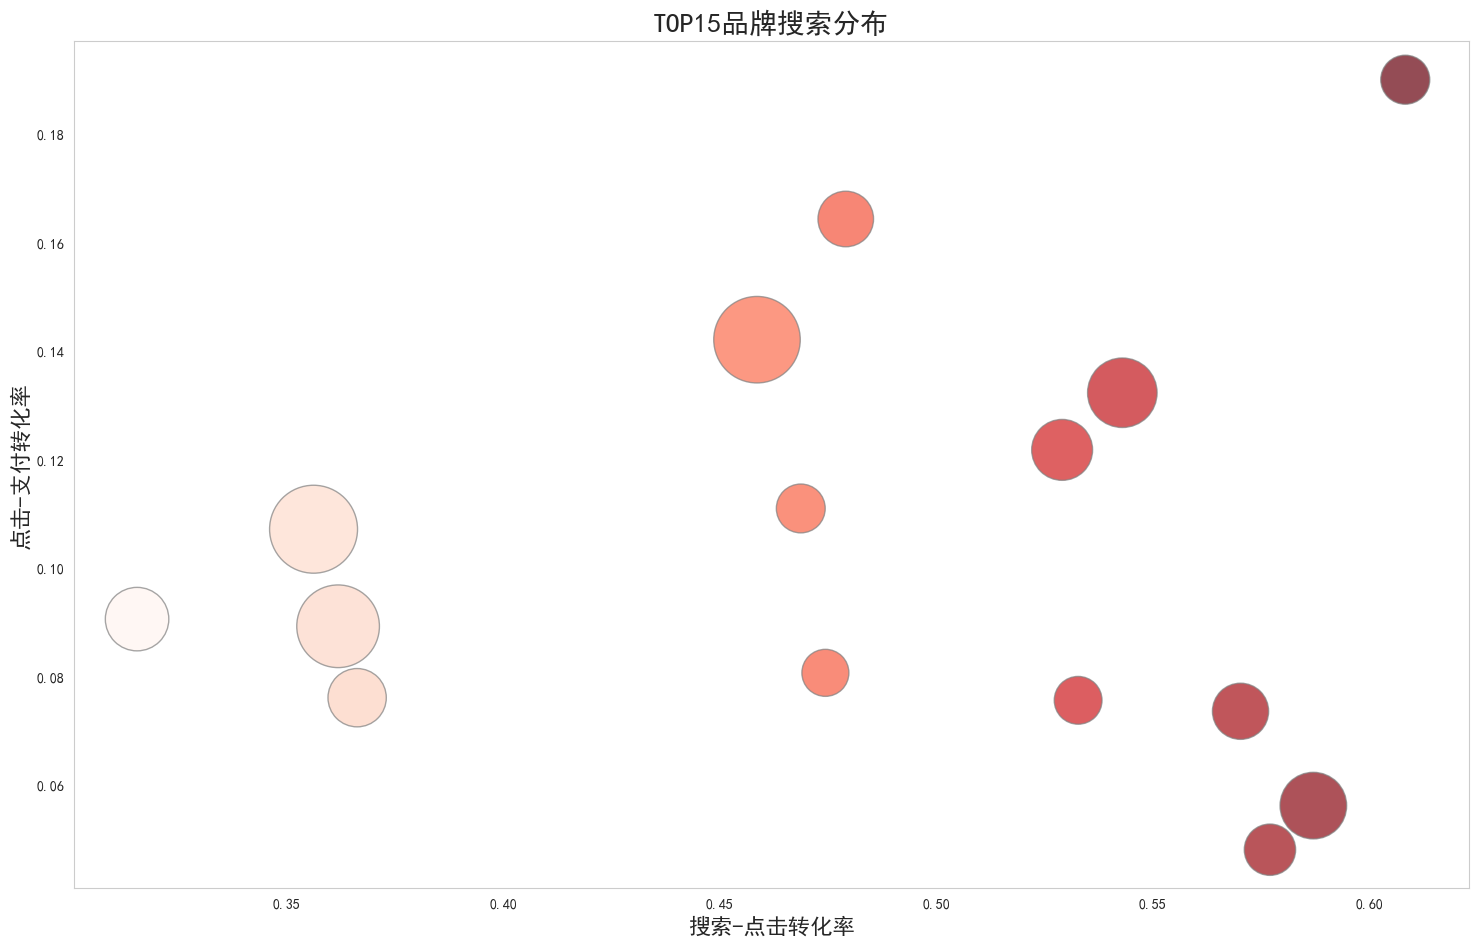

In [35]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
# 准备数据
x= display_data['搜索-点击转化率'].to_list()
y= display_data['点击-支付转化率'].to_list()
z= display_data['品牌搜索人数']
text= display_data['品牌'].to_list()
plt.figure(figsize=(18,11))
plt.scatter(x, y, s=z/400, c=x, cmap='Reds', alpha=0.7,edgecolors='grey',linewidths=1)
#s 散点的大小  c 颜色 cmap配置配色  alpha 透明度  edgecolors 汽包边缘的颜色   linewidths 线宽
plt.xlabel('搜索-点击转化率',size=16)
plt.ylabel('点击-支付转化率',size=16)
plt.title('TOP15品牌搜索分布',size=20) # 设置标题
plt.grid(False) # 关闭网格线
plt.show()

In [37]:
display_data

,品牌,品牌搜索人数,点击人数,支付人数,搜索-点击转化率,点击-支付转化率
12,双敏,1604198,571399,61244,0.36,0.11
3,九方,1552916,712139,101217,0.46,0.14
20,巨奥,1417267,512847,45790,0.36,0.09
15,商软,1002679,544392,72050,0.54,0.13
24,戴硕,920350,540284,30371,0.59,0.06
35,毕博,835493,263549,23879,0.32,0.09
38,盟新,769771,407238,49607,0.53,0.12
6,兰金,705190,258279,19659,0.37,0.08
31,昊嘉,654808,373391,27486,0.57,0.07
45,超艺,640732,306960,50461,0.48,0.16


In [40]:
text[0]

'双敏'

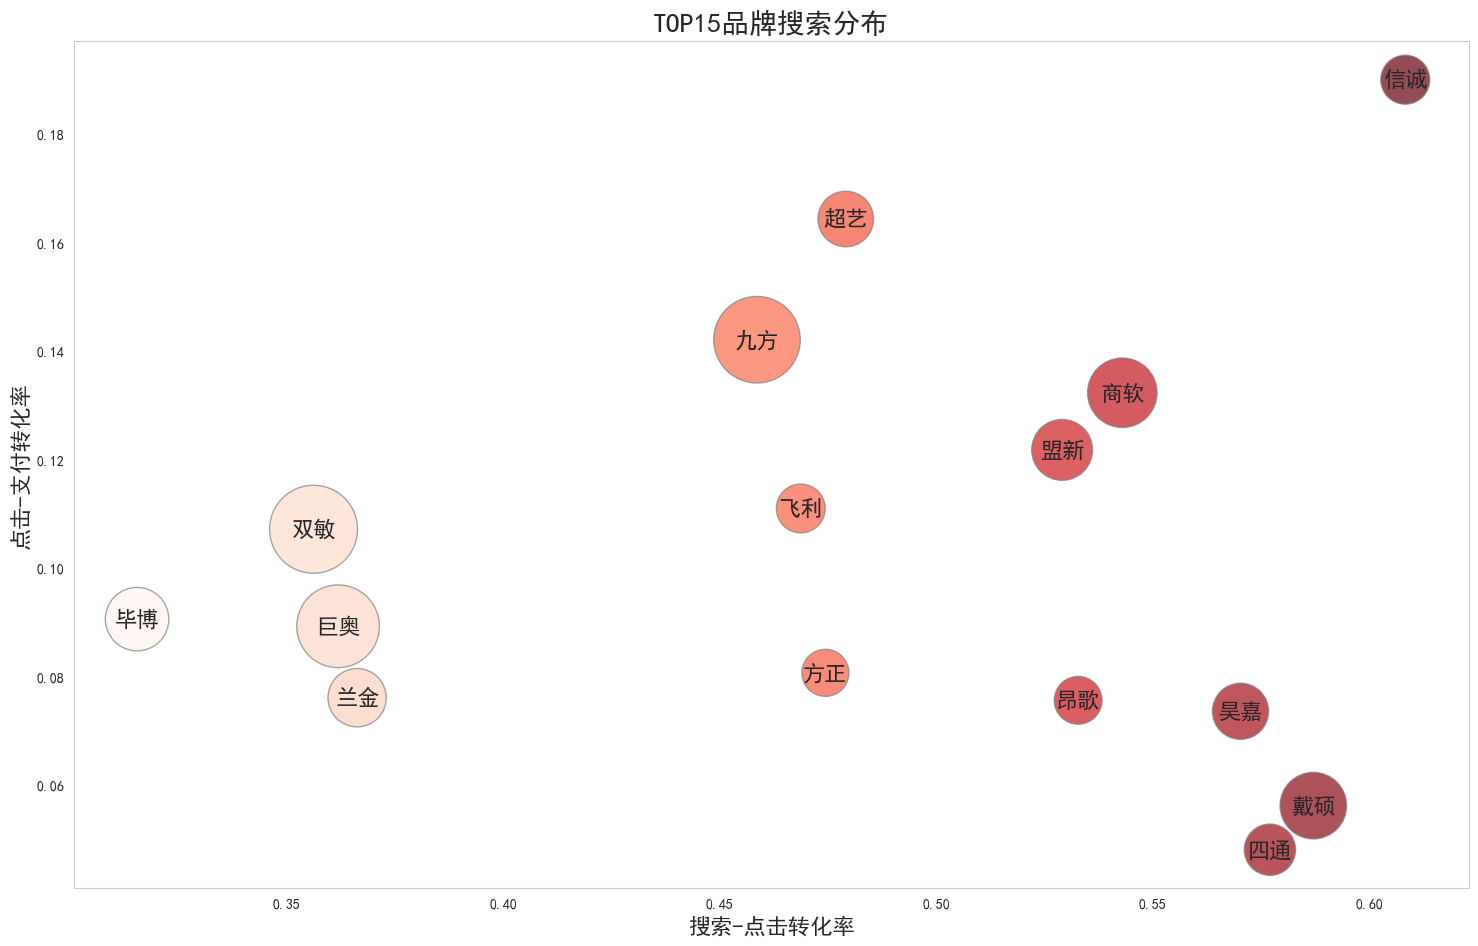

In [50]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
# 准备数据
x= display_data['搜索-点击转化率'].to_list()
y= display_data['点击-支付转化率'].to_list()
z= display_data['品牌搜索人数']
text= display_data['品牌'].to_list()
plt.figure(figsize=(18,11))
plt.scatter(x, y, s=z/400, c=x, cmap='Reds', alpha=0.7,edgecolors='grey',linewidths=1)
#s 散点的大小  c 颜色 cmap配置配色  alpha 透明度  edgecolors 汽包边缘的颜色   linewidths 线宽
for i in range(len(text)):
    # x,y 文字绘制的位置, s 要绘制的文字的内容, fontsize 字体大小
    # horizontalalignment verticalalignment 文字对齐的方式, 默认x,y指定的是文字的左下角的位置
    # horizontalalignment verticalalignment 都设置为center 居中, x,y指定的就是文字中心的位置
    plt.text(x=x[i], y=y[i], s=text[i], fontsize=16,horizontalalignment='center',verticalalignment='center')

plt.xlabel('搜索-点击转化率',size=16)
plt.ylabel('点击-支付转化率',size=16)
plt.title('TOP15品牌搜索分布',size=20) # 设置标题
plt.grid(False) # 关闭网格线
plt.show()

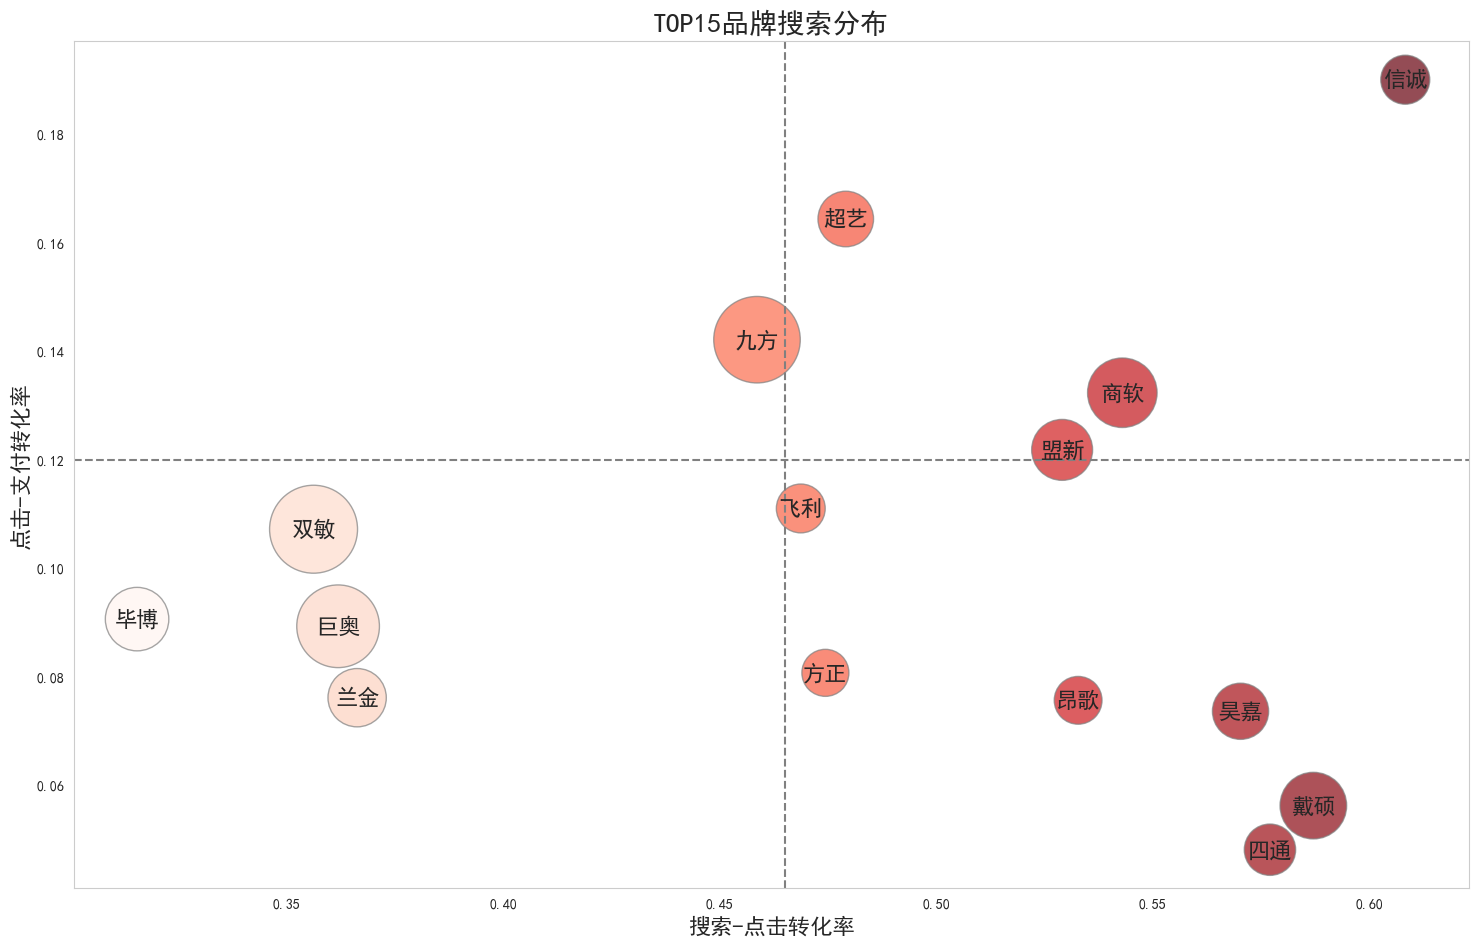

In [47]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
# 准备数据
x= display_data['搜索-点击转化率'].to_list()
y= display_data['点击-支付转化率'].to_list()
z= display_data['品牌搜索人数']
text= display_data['品牌'].to_list()
plt.figure(figsize=(18,11))
plt.scatter(x, y, s=z/400, c=x, cmap='Reds', alpha=0.7,edgecolors='grey',linewidths=1)
#s 散点的大小  c 颜色 cmap配置配色  alpha 透明度  edgecolors 汽包边缘的颜色   linewidths 线宽
for i in range(len(text)):
    # x,y 文字绘制的位置, s 要绘制的文字的内容, fontsize 字体大小
    # horizontalalignment verticalalignment 文字对齐的方式, 默认x,y指定的是文字的左下角的位置
    # horizontalalignment verticalalignment 都设置为center 居中, x,y指定的就是文字中心的位置
    plt.text(x=x[i], y=y[i], s=text[i], fontsize=16,horizontalalignment='center',verticalalignment='center')
plt.axhline(y=0.12, color='grey', linestyle='--') # horizontal 水平方向
plt.axvline(x=0.465, color='grey', linestyle='--') # vertical  垂直方向
plt.xlabel('搜索-点击转化率',size=16)
plt.ylabel('点击-支付转化率',size=16)
plt.title('TOP15品牌搜索分布',size=20) # 设置标题
plt.grid(False) # 关闭网格线
plt.show()